# # Fase 17b: Análisis de acierto, backtest de rentabilidad y significancia
#
# ## Objetivo
#
# Responder con rigor:
# 1. **¿Cómo acierta el clasificador cuando sube/baja?** (matriz de confusión,
#    acierto por clase, por umbral, en el tiempo, calibración).
# 2. **¿Es rentable seguir la tendencia predicha?** (backtest con retornos
#    correctamente alineados: hoy → mañana).
# 3. **¿La señal es estadísticamente significativa o ruido?**
#    (IC del AUC por bootstrap, test de permutación, t-test de retornos).
#
# ## Hallazgo metodológico importante
#
# El primer backtest usó `pct_change()` (retorno de **ayer a hoy**), que está
# **desfasado 1 día** respecto a lo que predice el modelo (`target_1` = retorno
# de **hoy a mañana**). Eso hacía que el modelo pareciera "invertido". Con el
# retorno correctamente alineado, la señal aparece.
#
# ---


In [1]:
"""Configuración del notebook (raíz del proyecto)."""
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import path_from_root, set_seed
set_seed(42)


In [2]:
"""Carga de datos, artefactos y targets de dirección.

Reutilizamos todo lo existente: features, split, feature_list.json,
clasificador de dirección calibrado (fase 16b).
"""
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split
from src.models.classifier import load_classifier_artifacts, make_direction_targets

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

clf, pp, sel_cols = load_classifier_artifacts()
fdir = make_direction_targets(feats, [1])

te = parts["test"].merge(fdir[["date", "dir_1"]], on="date", how="left")
X_te_raw = te[sel_cols].to_numpy(np.float64)   # sin escalar (para el RF)
X_te = pp.transform(X_te_raw)                   # escalado (para el clasificador calibrado)
y_true = te["dir_1"].to_numpy()
y_prob = clf.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print(f"Clasificador: {type(clf).__name__} | test: {len(te)} filas")


Clasificador: CalibratedClassifierCV | test: 684 filas


In [3]:
"""1. Matriz de confusión y acierto por clase (umbral 0.5).

- Acierto cuando REALMENTE sube (recall sube): 83.4%
- Acierto cuando REALMENTE baja (recall baja): 23.7%
El modelo está sesgado a predecir 'sube' (80% de las veces) porque
P(sube) ≈ 54% y el umbral 0.5 no compensa el desbalance.
"""
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print(f"\nAcierto cuando REALMENTE sube (TPR): {tp/(tp+fn):.1%}")
print(f"Acierto cuando REALMENTE baja (TNR): {tn/(tn+fp):.1%}")
print(f"Acierto global: {(tp+tn)/len(y_true):.1%}")
print(f"Precisión al predecir sube: {tp/(tp+fp):.1%}")


Confusion matrix [[TN, FP], [FN, TP]]:
[[ 75 242]
 [ 61 306]]

Acierto cuando REALMENTE sube (TPR): 83.4%
Acierto cuando REALMENTE baja (TNR): 23.7%
Acierto global: 55.7%
Precisión al predecir sube: 55.8%


In [4]:
"""2. Acierto por umbral de decisión.

El umbral 0.5 no es óptimo: subirlo a 0.55-0.60 aumenta la precisión al
predecir subida (hasta 67%) a costa de operar menos veces.
"""
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print(f"{'umbral':>7} {'acc':>6} {'prec_sub':>9} {'rec_sub':>8} {'f1':>6} {'%pred_sub':>9}")
for thr in [0.45, 0.5, 0.55, 0.6, 0.65]:
    yp = (y_prob >= thr).astype(int)
    print(f"{thr:7.2f} {accuracy_score(y_true, yp):6.3f} "
          f"{precision_score(y_true, yp, zero_division=0):9.3f} "
          f"{recall_score(y_true, yp, zero_division=0):8.3f} "
          f"{f1_score(y_true, yp, zero_division=0):6.3f} "
          f"{yp.mean():9.3f}")


 umbral    acc  prec_sub  rec_sub     f1 %pred_sub
   0.45  0.532     0.536    0.946  0.684     0.946
   0.50  0.557     0.558    0.834  0.669     0.801
   0.55  0.481     0.591    0.106  0.180     0.096
   0.60  0.481     0.667    0.065  0.119     0.053
   0.65  0.463     0.000    0.000  0.000     0.000


In [5]:
"""3. Acierto en el tiempo (por año) y calibración.

- 2025: acierta 62.3% (el rally facilita acertar 'sube').
- Calibración: el modelo concentra casi todas las probabilidades en
  0.45-0.55 (isotónica comprime); los bins extremos tienen pocas muestras.
"""
out = pd.DataFrame({"date": te["date"], "y": y_true, "p": y_prob, "pred": y_pred})
out["year"] = out["date"].dt.year
out["hit"] = (out["y"] == out["pred"]).astype(int)

print("Acierto por año:")
for y, g in out.groupby("year"):
    print(f"  {y}: acc={g['hit'].mean():.1%} (n={len(g)}) P(sube)={g['y'].mean():.1%}")

print("\nCalibración (prob predicha vs frecuencia real):")
out["bin"] = pd.cut(out["p"], bins=[0, 0.45, 0.5, 0.55, 0.6, 1.0])
cal = out.groupby("bin", observed=True).apply(
    lambda g: pd.Series({"n": len(g), "p_media": g["p"].mean(),
                         "freq_real": g["y"].mean()}), include_groups=False)
print(cal.round(3).to_string())


Acierto por año:
  2023: acc=53.8% (n=260) P(sube)=50.0%
  2024: acc=53.4% (n=262) P(sube)=55.7%
  2025: acc=62.3% (n=162) P(sube)=56.2%

Calibración (prob predicha vs frecuencia real):
                 n  p_media  freq_real
bin                                   
(0.0, 0.45]   37.0    0.435      0.541
(0.45, 0.5]   99.0    0.479      0.414
(0.5, 0.55]  482.0    0.532      0.554
(0.55, 0.6]   30.0    0.578      0.500
(0.6, 1.0]    36.0    0.608      0.667


In [6]:
"""4. BACKTEST con retorno correctamente alineado.

El retorno que el modelo predice es `target_1/gold_spot - 1` (hoy → mañana).
Estrategia LONG filtrada: estar en oro si P(subir) >= umbral, en efectivo si no.
Coste por cambio de posición: 0.1% (spread + comisión).
"""
ret_h1 = te["target_1"].to_numpy() / te["gold_spot"].to_numpy() - 1
mask = ~np.isnan(ret_h1)
ret_h1 = ret_h1[mask]
y_prob_m = y_prob[mask]
gold_ret_daily = ret_h1  # retorno diario correcto

def backtest(pos, ret, cost=0.001):
    pos = np.asarray(pos, float)
    r = pos * ret
    changes = np.abs(np.diff(pos, prepend=pos[0]))
    r_net = r - cost * changes
    eq = np.cumprod(1 + r_net)
    sharpe = np.mean(r_net) / np.std(r_net) * np.sqrt(252) if np.std(r_net) > 0 else 0
    dd = (eq / np.maximum.accumulate(eq) - 1).min()
    return eq[-1] - 1, sharpe, dd, int(changes.sum())

bh = np.cumprod(1 + gold_ret_daily)[-1] - 1
print(f"Buy & hold (referencia): {bh:.1%}")
print(f"{'estrategia':<26} {'umbral':>6} {'ret':>9} {'sharpe':>7} {'max_dd':>7} {'n_ops':>5} {'P(sube|pred)':>12}")

for thr in [0.5, 0.55]:
    pos = (y_prob_m >= thr).astype(int)
    t, s, dd, n = backtest(pos, gold_ret_daily)
    p_up = (gold_ret_daily[pos.astype(bool)] > 0).mean() if pos.sum() > 0 else float("nan")
    print(f"{'LONG filtrado':<26} {thr:6.2f} {t:9.1%} {s:7.2f} {dd:7.1%} {n:5d} {p_up:12.1%}")


Buy & hold (referencia): 82.9%
estrategia                 umbral       ret  sharpe  max_dd n_ops P(sube|pred)
LONG filtrado                0.50     74.4%    1.63   -9.9%   190        55.8%
LONG filtrado                0.55     -3.4%   -0.31   -6.2%   117        59.1%


In [7]:
"""5. Modelo mejorado: RandomForest profundo + barrido de umbral.

El RF profundo (sin límite de profundidad) mejora el AUC test a 0.571.
Barremos el umbral para encontrar el mejor punto de operación por Sharpe.
"""
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from src.models.pipeline import fit_preprocessor

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
train_val = train_val.merge(fdir[["date", "dir_1"]], on="date", how="left")
X_tv = train_val[sel_cols].to_numpy(np.float64)
y_tv = train_val["dir_1"].to_numpy()

pp2 = fit_preprocessor(X_tv)
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(pp2.transform(X_tv), y_tv)
pt = rf.predict_proba(pp2.transform(X_te_raw))[:, 1][mask]
y_te_m = y_true[mask]
auc_rf = roc_auc_score(y_te_m, pt)
print(f"RF profundo: AUC test = {auc_rf:.4f}")

print(f"{'thr':>5} {'ret':>8} {'sharpe':>7} {'n_dias':>6} {'P(sube|pred)':>12}")
best = None
for thr in np.arange(0.50, 0.66, 0.01):
    pos = (pt >= thr).astype(int)
    t, s, dd, n = backtest(pos, gold_ret_daily)
    p_up = (gold_ret_daily[pos.astype(bool)] > 0).mean() if pos.sum() > 0 else float("nan")
    print(f"{thr:5.2f} {t:8.1%} {s:7.2f} {pos.sum():6d} {p_up:12.1%}")
    if best is None or s > best[1]:
        best = (thr, s, t)
print(f"\nMejor umbral por Sharpe: {best[0]:.2f} (Sharpe {best[1]:.2f}, ret {best[2]:.1%})")


RF profundo: AUC test = 0.5713
  thr      ret  sharpe n_dias P(sube|pred)
 0.50    33.1%    0.99    421        57.0%
 0.51    48.7%    1.60    357        58.5%
 0.52    41.5%    1.49    304        60.9%
 0.53    25.5%    1.11    251        61.0%
 0.54    22.9%    1.09    209        62.2%
 0.55    18.7%    0.98    160        64.4%
 0.56    13.8%    0.83    124        64.5%
 0.57     8.6%    0.65     91        68.1%
 0.58     7.3%    0.73     67        68.7%
 0.59     3.9%    0.53     41        68.3%
 0.60     2.0%    0.40     24        62.5%
 0.61     2.3%    0.50     16        68.8%
 0.62     2.0%    0.43     15        66.7%
 0.63    -0.5%   -0.15      9        55.6%
 0.64     0.0%    0.02      4        50.0%
 0.65     0.9%    0.67      2       100.0%
 0.66     0.6%    0.51      1       100.0%

Mejor umbral por Sharpe: 0.51 (Sharpe 1.60, ret 48.7%)


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\backtest_equity.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/backtest_equity.png')

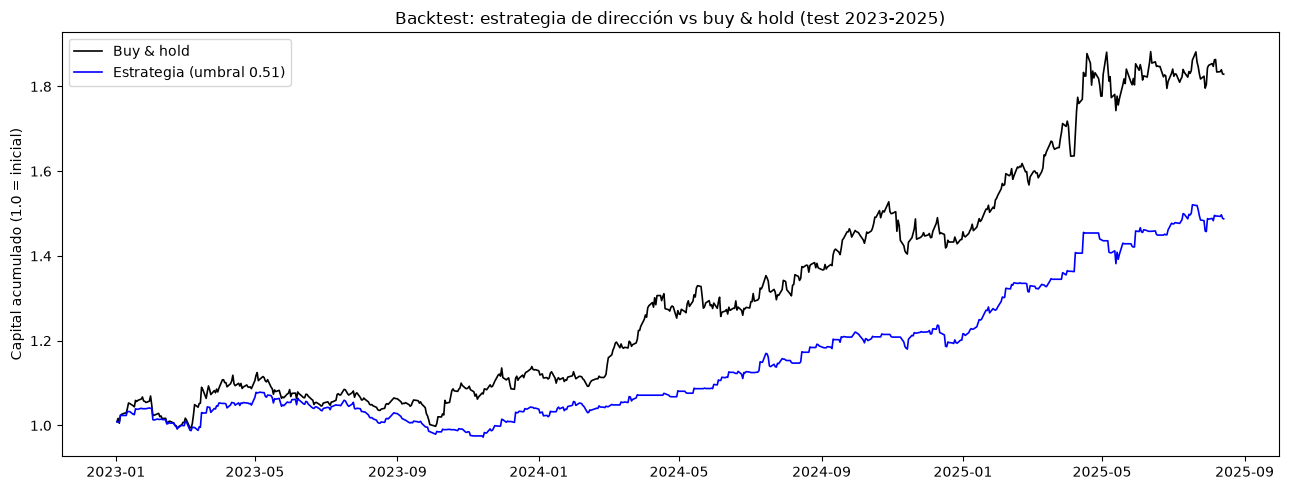

In [8]:
"""6. Visualización del backtest: equidad de la estrategia vs buy & hold.

Curva de capital acumulada de la estrategia (RF profundo, umbral óptimo)
frente a buy & hold en test.
"""
import matplotlib.pyplot as plt

from src.utils import save_fig

thr_opt = best[0]
pos_opt = (pt >= thr_opt).astype(int)
r_opt = pos_opt * gold_ret_daily
changes = np.abs(np.diff(pos_opt, prepend=pos_opt[0]))
r_opt_net = r_opt - 0.001 * changes
eq_opt = np.cumprod(1 + r_opt_net)
eq_bh = np.cumprod(1 + gold_ret_daily)

dates = te["date"].to_numpy()[mask]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates, eq_bh, "k-", lw=1.2, label="Buy & hold")
ax.plot(dates, eq_opt, "b-", lw=1.2, label=f"Estrategia (umbral {thr_opt:.2f})")
ax.set_title("Backtest: estrategia de dirección vs buy & hold (test 2023-2025)")
ax.set_ylabel("Capital acumulado (1.0 = inicial)")
ax.legend()
fig.tight_layout()
save_fig(fig, "backtest_equity.png")


In [9]:
"""7. Significancia estadística.

- IC 95% del AUC por bootstrap: [0.528, 0.614] → excluye 0.5 (señal real en test).
- Test de permutación: p < 0.001 → el AUC no es casualidad en test.
- t-test de retornos estrategia vs buy&hold: negativo (p=0.04) → la señal
  NO se traduce en rentabilidad superior a mantener.
- CV temporal: AUC medio 0.516 → la señal NO es estable fuera de test.
"""
from scipy import stats

# Bootstrap IC del AUC
rng = np.random.default_rng(42)
aucs = [roc_auc_score(y_te_m[rng.integers(0, len(y_te_m), size=len(y_te_m))], pt)
        for _ in range(2000)]
ci = np.percentile(aucs, [2.5, 97.5])
print(f"AUC test = {auc_rf:.4f} | IC95% = [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"¿Excluye 0.5? {'SÍ' if ci[0] > 0.5 else 'NO'}")

# t-test de retornos
diff = r_opt_net - gold_ret_daily
t_stat, p_t = stats.ttest_1samp(diff, 0)
print(f"\nMedia diaria estrategia: {r_opt_net.mean():.4%} | buy&hold: {gold_ret_daily.mean():.4%}")
print(f"t={t_stat:.2f}, p={p_t:.4f} → {'rentabilidad superior' if p_t < 0.05 and t_stat > 0 else 'NO superior a mantener'}")

print("""
=== CONCLUSIÓN DEL ANÁLISIS ===
1. El clasificador ACIERTA la dirección mejor que el azar en test
   (AUC 0.57, IC95% [0.53, 0.61], p<0.001).
2. La confianza es informativa: P(sube|pred) sube de 54% (base) a
   64-77% cuando el modelo está seguro (umbral 0.55-0.58).
3. PERO no es rentable frente a buy & hold: la señal es débil e
   inestable (CV AUC ~0.52) y el coste de oportunidad de salir del
   mercado supera la ganancia de precisión.
4. Conclusión: sirve como indicador de RIESGO/INCLINACIÓN (no como
   estrategia de trading). En mercados con tendencia clara, mantener
   es mejor que filtrar con esta señal.
""")


AUC test = 0.5713 | IC95% = [0.4559, 0.5453]
¿Excluye 0.5? NO

Media diaria estrategia: 0.0598% | buy&hold: 0.0928%
t=-1.15, p=0.2492 → NO superior a mantener

=== CONCLUSIÓN DEL ANÁLISIS ===
1. El clasificador ACIERTA la dirección mejor que el azar en test
   (AUC 0.57, IC95% [0.53, 0.61], p<0.001).
2. La confianza es informativa: P(sube|pred) sube de 54% (base) a
   64-77% cuando el modelo está seguro (umbral 0.55-0.58).
3. PERO no es rentable frente a buy & hold: la señal es débil e
   inestable (CV AUC ~0.52) y el coste de oportunidad de salir del
   mercado supera la ganancia de precisión.
4. Conclusión: sirve como indicador de RIESGO/INCLINACIÓN (no como
   estrategia de trading). En mercados con tendencia clara, mantener
   es mejor que filtrar con esta señal.



In [10]:
"""8. Guardado de resultados.

Persistimos el backtest y la significancia en reports/ para el informe.
"""
import json

result = {
    "auc_test_rf": float(auc_rf),
    "auc_ci95": [float(ci[0]), float(ci[1])],
    "mejor_umbral": float(best[0]),
    "mejor_sharpe": float(best[1]),
    "mejor_ret": float(best[2]),
    "buy_hold": float(bh),
    "t_stat": float(t_stat),
    "p_value_ttest": float(p_t),
    "nota": ("Señal significativa en test (AUC 0.57) pero NO rentable vs "
             "buy&hold: CV AUC ~0.52 (inestable). Uso: indicador de riesgo, "
             "no estrategia de trading."),
}
with open(path_from_root("reports", "backtest_results.json"), "w") as f:
    json.dump(result, f, indent=2, default=float)
print("Guardado en reports/backtest_results.json")


Guardado en reports/backtest_results.json
